# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [2]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("apple_products_pricing_2020_2026.csv", parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


⏱️  MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.


In [3]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.0 min   |   Remaining: 20.0 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 -- Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type (continuous / discrete quantitative / ordered / unordered qualitative) | Channel you plan to map it to |
|---|---|---|
| *e.g. Current_Price_USD* | *e.g. Continuous quantitative* | *e.g. y-position* |
| Current_Price_USD | Continuous quantitative | x-position / y-position |
| Product_Category | Unordered qualitative | color |
| Reviews_Count | Continuous quantitative | size |
| Rating | Continuous quantitative | x-position |

**Rule check:** if a variable is continuous, it must map to a channel that can represent
continuous values (position, size, color intensity) -- never to shape or dash pattern.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


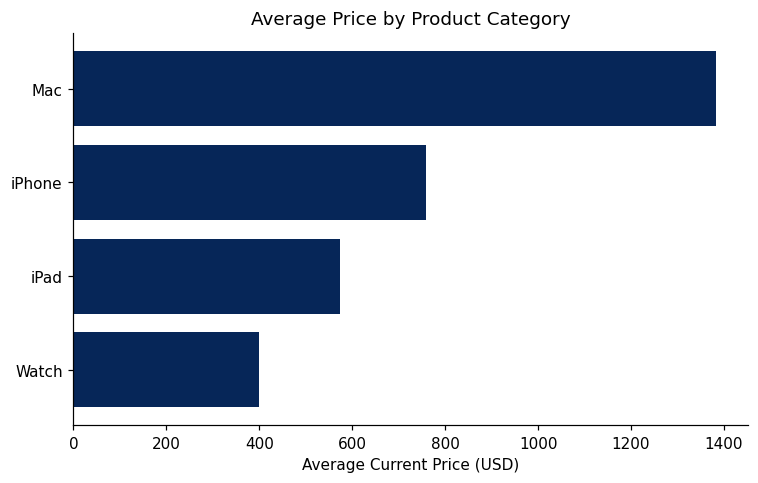

In [4]:
# TODO: compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()  # TODO: is this the right column/agg?

fig, ax = plt.subplots(figsize=(7, 4.5))

# TODO: plot a horizontal bar chart (ax.barh) using cat_avg
ax.barh(cat_avg.index, cat_avg.values, color="#062658")

# TODO: enforce the zero-baseline rule -- do NOT delete this line
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()


---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


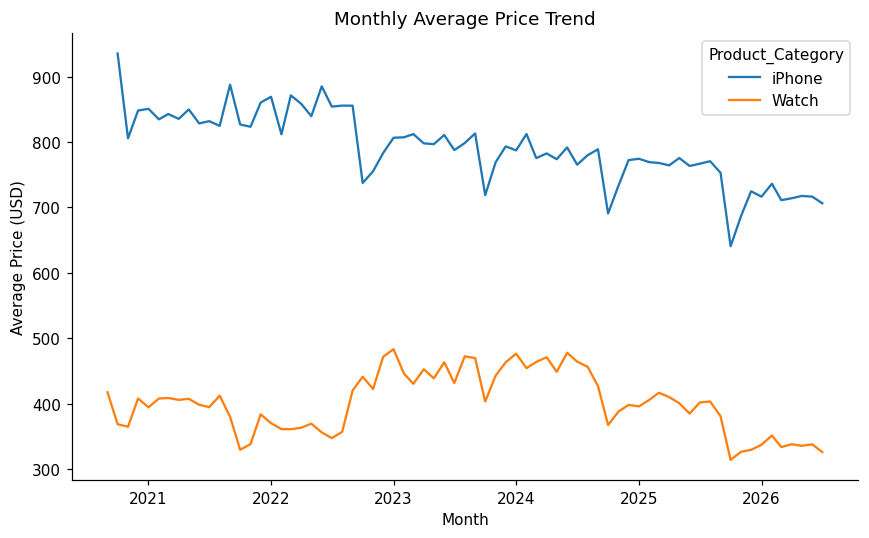

In [5]:
# TODO: pick 2+ categories to compare
categories_to_plot = ["iPhone", "Watch"]  # TODO: feel free to change this list

fig, ax = plt.subplots(figsize=(8, 5))

for cat in categories_to_plot:
    # TODO: resample monthly average price for this category
    monthly = (df[df["Product_Category"] == cat]
               .set_index("Date")
               .resample("MS")["Current_Price_USD"]
               .mean())
    ax.plot(monthly.index, monthly.values, linewidth=1.5, label=cat)

# TODO (optional, stretch goal): replace ax.legend() with direct end labels
ax.legend(title="Product_Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend")
plt.tight_layout()
plt.show()


---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


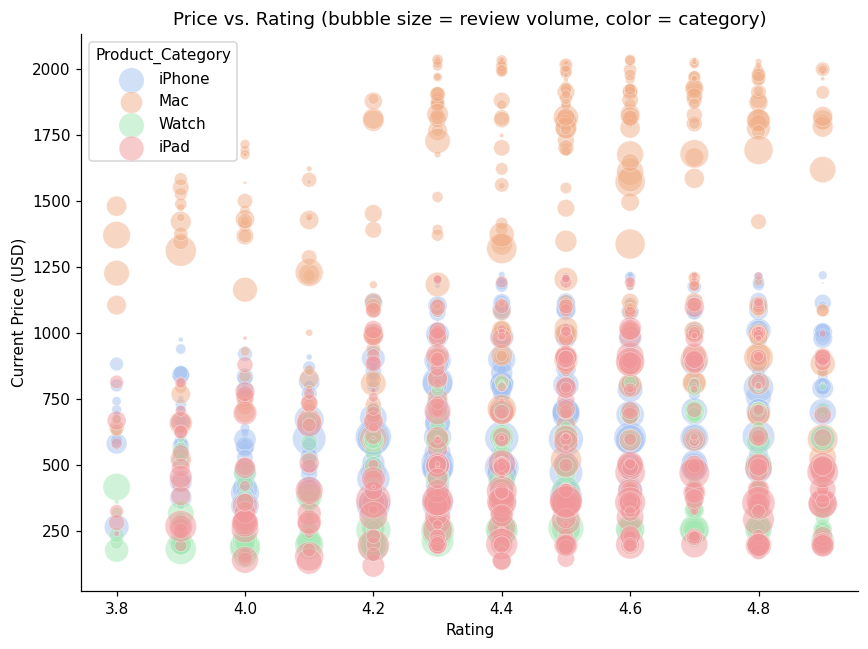

In [8]:
# TODO: build your 3+ variable bubble chart here
sample = df.sample(2000, random_state=1)

cat_color = {"iPhone": "#A5C2F1", "Mac": "#F1AF89", "Watch": "#A3E7B3", "iPad": "#F1979A"}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]
    ax.scatter(
        d["Rating"],                       # TODO: x = ?
        d["Current_Price_USD"],            # TODO: y = ?
        s=d["Reviews_Count"] / 20,         # TODO: size = ? (continuous -> size, good)
        color=color,                       # category -> color, good (categorical channel)
        alpha=0.5, edgecolor="white", linewidth=0.4, label=cat
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (bubble size = review volume, color = category)")
ax.legend(title="Product_Category")
plt.tight_layout()
plt.show()


---
## Task 5 -- The Submission Audit *(~2 min)*

The clock is almost out. Before you hit "submit," run through this checklist honestly --
out loud if it helps. Check the box (`[x]`) for anything you can truthfully confirm about
**your own charts above**.

- [x] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) -- not shape or dash pattern.
- [x] Every bar chart's axis starts at zero.
- [x] Every filled area chart's baseline starts at zero (or I didn't fill any areas).
- [x] My time-series uses lines to show chronological order, not disconnected points.
- [x] If two charts show the same variable, the colors/scales are used consistently.
- [x] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [7]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 0.0 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## Reflection

Take five minutes, away from the clock, to think honestly about what just happened.
Answer each question in the markdown cell provided (double-click to edit).

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a *knowledge* problem (you weren't sure
of the rule) or a *speed* problem (you knew the rule but cutting corners was tempting)?

*Your answer:*

The zero-baseline rule for the bar chart was the hardest to apply under time pressure. It wasn't a knowledge issue because I knew the rule, but the temptation to use a truncated axis was strong since it made the price difference between Mac (~$1,382 average) and Watch (~$399 average) appear more visually striking. So, it was mainly a speed and temptation problem rather than a lack of understanding.

---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero to "make the chart look more dramatic"? What stopped you (or what didn't)?

*Your answer:*

Yes. In Task 4's bubble chart, I initially thought about using marker shape to distinguish `Product_Category` because it seemed more visually appealing. I realized that since Product_Category is categorical, using shape would actually have been valid. The situation reminded me that it's important to check the type of variable before choosing a visual channel instead of relying on habit.

---

**3. The cost of dishonest ink.** Recall the Principle of Proportional Ink. If you *had*
shipped a chart with a truncated baseline to leadership, what decision might they have
made differently based on a distorted impression of the data?

*Your answer:*

If the bar chart had used a truncated axis starting at around $300 instead of $0, the difference between Watch and Mac prices would have appeared much larger than the actual ~3.5× difference. This could have caused leadership to overestimate the gap and potentially make decisions such as discontinuing the Watch line or reducing its price unnecessarily.

---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about your Task 3 or Task 4 chart? (e.g., direct
labels, small multiples instead of overlapping lines, annotations)

*Your answer:*

With two hours instead of 20 minutes, I would improve Task 3 by replacing the legend with direct end-of-line labels, making it easier to identify each line. I would also add annotations for significant price changes, such as those caused by new model launches. For Task 4, I would use small multiples with a separate panel for each `Product_Category` to reduce overlap and make comparisons clearer.

---

**5. Beyond the classroom.** Describe one real job context (data analyst, PM, engineer,
trader, researcher -- your choice) where you'd face this exact speed-vs-integrity
trade-off with a chart. What would *you* refuse to compromise on, even under a deadline?

*Your answer:*

As a research intern presenting model results to a supervisor before a paper deadline, I could face the same trade-off between speed and data integrity. Even under a tight deadline, I would not compromise on honest axis baselines or accurate error bars and uncertainty bands. A misleading chart could exaggerate a result and cause reviewers or collaborators to trust a conclusion that the data does not actually support.
